In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import pandas as pd
import glob
import os
import rasterio as rio
from sklearn.metrics import r2_score, mean_squared_error 

In [20]:
# import skgstat as skg

In [1]:
# !conda install -c conda-forge scikit-gstat

In [2]:
def read_ground_data_mat(filepath):
    rd = scipy.io.loadmat(filepath) # load the mat file
    DATA = rd['DATA']
    x = rd['X']
    y = rd['Y']
    
    return DATA, x, y

In [3]:
# ground data files
ground_data_folder = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ground_data/'
os.listdir(ground_data_folder)

['lidar_depths_1m.tif',
 'isnobal_SWE.mat',
 '.DS_Store',
 'lidar_depths.mat',
 'isnobal_depths_10m.tif.aux.xml',
 'lidar_depths_10m.tif',
 'cores_depths_3m.tif.aux.xml',
 'measured_depths.mat',
 'lidar_depths_3m.tif.aux.xml',
 'cores_depths.mat',
 'isnobal_depths_3m.tif',
 'measured_depths_3m.tif',
 'isnobal_depths_10m.tif',
 'cores_density.mat',
 'cores_SWE.mat',
 'isnobal_depths_1m.tif',
 'lidar_depths_3m.tif',
 'isnobal_depths.mat',
 'lidar_depths_10m.tif.aux.xml',
 'isnobal_SWE_1m.tif',
 'cores_depths_3m.tif']

# 1) Read and display data

In [23]:
fname = 'cores_depths.mat'
[DATA, X, Y] = read_ground_data_mat(ground_data_folder+fname)

In [87]:
# print(DATA)

### A: gridded data

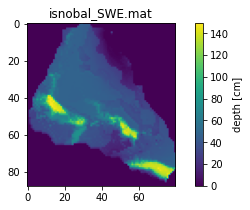

In [120]:
# for gridded data, imshow:
plt.figure(figsize=(7,3))
plt.imshow(DATA)
# plt.xticks(X.flatten())
# plt.yticks(Y.flatten())
cbar = plt.colorbar(); cbar.set_label('depth [cm]')
plt.title(fname)
plt.show()

### B: point data

In [24]:
# Remove out of bounds data
X_in = X[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
Y_in = Y[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
DATA_in = DATA[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]

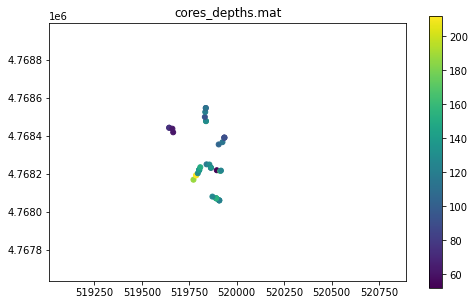

In [25]:
# for point/transect data, plot:
# list(zip(DATA, X< )
plt.figure(figsize=(8,5))
plt.scatter(X_in,Y_in,c=DATA_in.flatten(),s=25)
plt.colorbar()
plt.title(fname)
plt.gca().set_aspect('equal')
plt.xlim(519012,520895); plt.ylim(4767635,4768996)
plt.show()

# 2) Create Xm grid from the lidar data bounds/grid

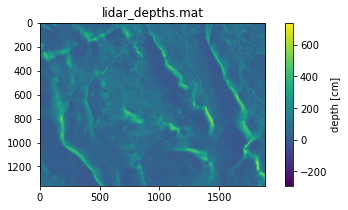

(1362, 1884)


In [4]:
# # step 1: create the 3 meter grid (center Xs and Ys) from the lidar dataset (1 m)
new_res = 1 # meter spacing for grid

[lidar_DATA, lidar_X, lidar_Y] = read_ground_data_mat(ground_data_folder+'lidar_depths.mat')
lidar_X = lidar_X.flatten()
lidar_Y = lidar_Y.flatten()

# determine where edges lie
edge_X_min = np.min(lidar_X)-0.5; edge_X_max = np.max(lidar_X)+0.5
edge_Y_top = np.max(lidar_Y)+0.5; edge_Y_bottom = np.min(lidar_Y)-0.5

grid_X = np.arange(edge_X_min+new_res/2, edge_X_max, new_res)
grid_Y = np.arange(edge_Y_top, edge_Y_bottom+new_res/2, -new_res)

plt.figure(figsize=(7,3)); plt.imshow(lidar_DATA); plt.title('lidar_depths.mat'); 
cbar = plt.colorbar(); cbar.set_label('depth [cm]'); plt.show()
print(lidar_DATA.shape)

# 3) Interpolate ground data to Xm grid

### A: Resample gridded data

In [89]:
from scipy.interpolate import interp2d

(1362, 1884)
Resampled to new dimensions: (1362, 1884)


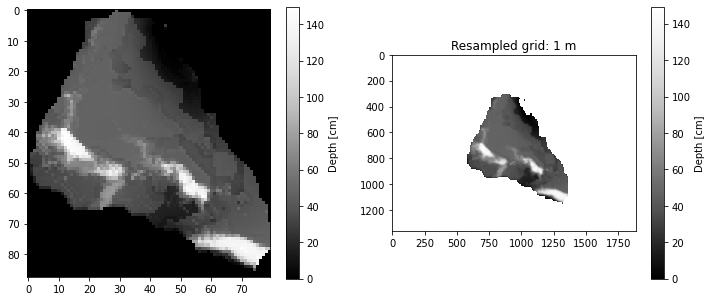

Save resampled grid to /Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ground_data/isnobal_SWE_1m.tif


In [90]:
outfile = fname[:-4]+'_'+str(new_res)+'m.tif'
outpath = ground_data_folder


# Create thew new x and y grid values using DEM bounds and the chipsize
resamp = np.zeros((len(grid_Y), len(grid_X))) # create an empty resampled DEM grid
print(resamp.shape)

# Resample to your new DEM bounds
f = interp2d(X.flatten(), Y.flatten(), DATA, fill_value=np.NaN) # create DEM interpolation object
resamp = f(grid_X,grid_Y) # resample the NIR data to the DSM coordinates
resamp = np.flipud(resamp) # flip up down
resamp[resamp==0.0] = np.NaN # convert 0 depths to NaNs
print("Resampled to new dimensions:",resamp.shape)

# Display the two DEMs as a visual check
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5))
im1 = ax1.imshow(DATA, cmap='Greys_r', vmin=0)
# ax1.set_title('Original DEM: '+str(refdem.transform[0])+' m') # original spatial resolution
fig.colorbar(im1, ax=ax1,label='Depth [cm]')

im2 = ax2.imshow(resamp, cmap='Greys_r', vmin=0)
ax2.set_title('Resampled grid: '+str(new_res)+' m') # new spatial resolution
fig.colorbar(im2, ax=ax2,label='Depth [cm]')
plt.show()

# Save the resampled DEM to georeferenced tif file
print("Save resampled grid to", outpath+outfile)
with rio.open(outpath+outfile,'w',
                  driver='GTiff',
                  height=resamp.shape[0], # new shape
                  width=resamp.shape[1], # new shape
                  dtype=resamp.dtype, # data type
                  count=1,
                  crs='EPSG:32611', # the EPSG for Reynolds Mounain
                  transform=rio.Affine(new_res, 0.0, edge_X_min, # modified transform
                                       0.0, -new_res, edge_Y_top)) as dst:
        dst.write(resamp, 1)

### B: IDW spatial interpolation of point data

In [429]:
from scipy.interpolate import griddata

In [430]:
points = np.array(list(zip(X_in.flatten(), Y_in.flatten()))) # zip points
points.shape

(762, 2)

In [431]:
values = DATA_in
values = values.flatten()
values.shape

(762,)

In [432]:
mesh_x, mesh_y = np.meshgrid(grid_X, grid_Y) # meshgrid

In [433]:
interpolated_grid = griddata(points, values, (mesh_x, mesh_y), method='cubic', fill_value = np.nan)
interpolated_grid.shape

(454, 628)

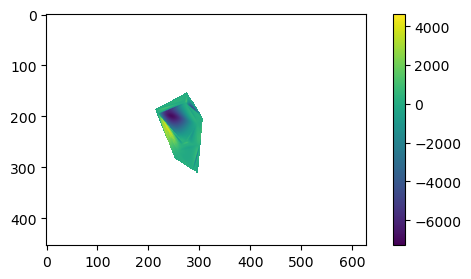

In [434]:
fig, ax = plt.subplots(figsize=(7,3))
# contour = ax.tricontourf(X.flatten(), Y.flatten(), values)
# plt.scatter(X.flatten(), Y.flatten(), marker='^',color='red')
plt.imshow(interpolated_grid)
plt.colorbar()
# plt.xlim(519012,520895); plt.ylim(4767635,4768996)
plt.show()

In [288]:
# save
outfile = fname[:-4]+'_'+str(new_res)+'m.tif'
outpath = ground_data_folder

with rio.open(outpath+outfile,'w',
                  driver='GTiff',
                  height=interpolated_grid.shape[0], # new shape
                  width=interpolated_grid.shape[1], # new shape
                  dtype=interpolated_grid.dtype, # data type
                  count=1,
                  crs='EPSG:32611', # the EPSG for Reynolds Mounain
                  transform=rio.Affine(new_res, 0.0, edge_X_min, # modified transform
                                       0.0, -new_res, edge_Y_top)) as dst:
        dst.write(interpolated_grid, 1)

In [13]:
# from sklearn.neighbors import KNeighborsRegressor

In [117]:
# # # step 1: create the 3 meter grid (center Xs and Ys) from the lidar dataset (1 m)
# new_res = 3 # meter spacing for grid
# fname = 'lidar_depths.mat'
# [lidar_DATA, lidar_X, lidar_Y] = read_ground_data_mat(ground_data_folder+fname)
# lidar_X = lidar_X.flatten()
# lidar_Y = lidar_Y.flatten()

# # determine where edges lie
# edge_X_min = np.min(lidar_X)-0.5; edge_X_max = np.max(lidar_X)+0.5
# edge_Y_top = np.max(lidar_Y)+0.5; edge_Y_bottom = np.min(lidar_Y)-0.5

# grid_X = np.arange(edge_X_min+new_res/2, edge_X_max, new_res)
# grid_Y = np.flip(np.arange(edge_Y_bottom+new_res/2, edge_Y_top, new_res))

# # # meshgrid the coordinates
# # all_Xs = np.meshgrid(grid_X, grid_Y)[0].ravel()
# # all_Ys = np.meshgrid(grid_X, grid_Y)[1].ravel()

# # # create data frame 
# # itrp = pd.DataFrame()
# # itrp['X'] = all_Xs
# # itrp['Y'] = all_Ys

In [63]:
# EXTRA STEP WITH GRIDDED DATA TO GET X, Y, DATA AS ITS OWN THING


In [64]:
# # grab a data frame with data to interpolate
# ground_data_df = pd.DataFrame(list(zip(X.flatten(), Y.flatten(), DATA.flatten())), columns=['X','Y','data'])
# ground_data_df.head()

In [65]:
# coords = ground_data_df[['X','Y']]
# values = ground_data_df['data']

In [66]:
# # predict the model is the IDW interpolation
# model = KNeighborsRegressor(algorithm='kd_tree', n_neighbors=25, weights='distance').fit(coords, values)
# pred=model.predict(itrp[['X','Y']])
# itrp['interp_data'] = pred

In [67]:
# itrp.head()

In [61]:
# plt.scatter(itrp['X'],itrp['Y'],c=itrp['interp_data'])
# plt.colorbar()
# plt.show()

# 4) Compare datasets

In [4]:
# ground data files
ground_data_folder = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ground_data/'
os.listdir(ground_data_folder)

['lidar_depths_1m.tif',
 'isnobal_SWE.mat',
 '.DS_Store',
 'lidar_depths.mat',
 'isnobal_depths_10m.tif.aux.xml',
 'lidar_depths_10m.tif',
 'cores_depths_3m.tif.aux.xml',
 'measured_depths.mat',
 'lidar_depths_3m.tif.aux.xml',
 'cores_depths.mat',
 'isnobal_depths_3m.tif',
 'measured_depths_3m.tif',
 'isnobal_depths_10m.tif',
 'cores_density.mat',
 'cores_SWE.mat',
 'isnobal_depths_1m.tif',
 'lidar_depths_3m.tif',
 'isnobal_depths.mat',
 'lidar_depths_10m.tif.aux.xml',
 'isnobal_SWE_1m.tif',
 'cores_depths_3m.tif']

### A: two grids of data

In [54]:
# read in tifs and subtract and plot
fname1 = 'isnobal_depths_1m.tif'
file1 = rio.open(ground_data_folder+fname1) # open 
data1 = file1.read(1) 

fname2 = 'isnobal_SWE_1m.tif'
file2 = rio.open(ground_data_folder+fname2) # open
data2 = file2.read(1) # read in the first and only band (elevations)

In [6]:
# # subtract
# plt.figure(figsize=(10,4))
# plt.imshow(data1-data2, cmap='RdBu',vmin=-400,vmax=400)
# cbar = plt.colorbar(); cbar.set_label('depth difference [cm]')
# plt.title(fname1+' - '+fname2)
# plt.show()

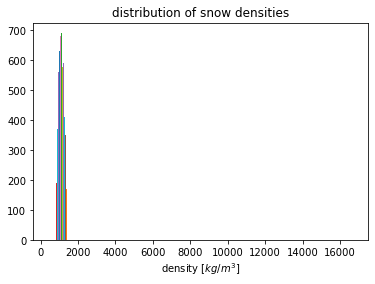

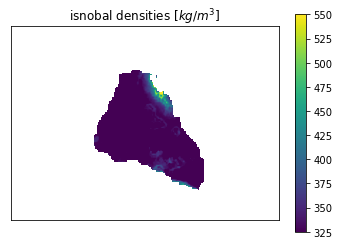

In [60]:
# calculation of density
calculated_density = (np.array(data2)/100)/(np.array(data1)/100)*1000 # SWE [m] / snow depths [m] * 1000 to convert to kg/m3

plt.figure(figsize=(6,4))
plt.hist(calculated_density)
plt.title('distribution of snow densities')
plt.xlabel('density [$kg/m^3$]')
plt.show()

plt.figure(figsize=(6,4))
plt.imshow(calculated_density, cmap='viridis', vmin=325,vmax=550)
cbar = plt.colorbar(); #cbar.set_label('depth difference [cm]')
plt.xticks([]); plt.yticks([])
plt.title('isnobal densities [$kg/m^3$]')
plt.show()

### B: points and gridded data

In [137]:
# # # read in tifs and subtract and plot
fname1 = 'lidar_depths_1m.tif'
file1 = rio.open(ground_data_folder+fname1) # open 
data1 = file1.read(1) 
# data1 = calculated_density

fname2 = 'measured_depths.mat'
[DATA, X, Y] = read_ground_data_mat(ground_data_folder+fname2)
X = X.flatten(); Y = Y.flatten(); data2 = DATA.flatten()

# Remove out of bounds data
X_in = X[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
Y_in = Y[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
DATA_in = DATA[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]

In [138]:
# find nearest idxs
x_idxs = []; y_idxs = []
for i in range(0, len(X_in)):
    x = X_in[i]; y = Y_in[i]

    x_idxs.append(np.argmin(np.abs(grid_X-x)))
    y_idxs.append(np.argmin(np.abs(grid_Y-y)))
# print(x_idxs, y_idxs)

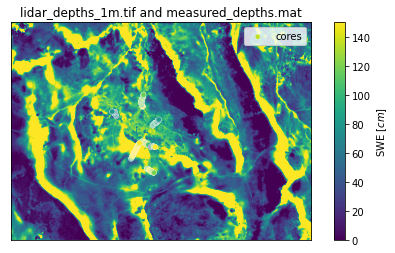

In [139]:
# plot
plt.figure(figsize=(8,4))
plt.imshow(data1,vmin=0, vmax=150)
cbar1 = plt.colorbar(); cbar1.set_label('SWE [$cm$]')
plt.scatter(x_idxs, y_idxs, c=DATA_in, marker='o',edgecolor='white',linewidth=0.2,s=25,vmin=0, vmax=150)
# cbar2 = plt.colorbar(); cbar2.set_label('measured depth [$cm$]')
plt.title(fname1+' and '+fname2)
plt.legend(['cores'])
plt.yticks([]); plt.xticks([])
plt.show()

In [ ]:
# compare densities only 
plt.figure(figsize=(8,4))
plt.imshow(data1,vmin=325, vmax=550)
#cbar1 = plt.colorbar(); cbar1.set_label('modeled density [$kg/m^3$]')
plt.scatter(x_idxs, y_idxs, c=DATA_in, marker='o',edgecolor='black',s=35,vmin=325, vmax=550)
cbar2 = plt.colorbar(); cbar2.set_label('measured density [$kg/m^3$]')
plt.title(fname1+' and '+fname2)
# plt.title('calculated densities vs. measured densities')
plt.legend(['modeled', 'cored'])
plt.yticks([]); plt.xticks([])
plt.show()

In [1]:
# import numpy as np


# V = skg.Variogram(coordinates=coordinates, values=values)
# V.plot()

ModuleNotFoundError: No module named 'skgstat'

In [49]:
# grab difference in depth at points
gridded_depths_at_points = data1[y_idxs, x_idxs].flatten()
diff = gridded_depths_at_points - DATA_in.flatten()

plt.figure(figsize=(10,4))
plt.imshow(data1,vmin=0,vmax=150)
cbar1 = plt.colorbar(); cbar1.set_label('calculated density [$kg/m^3$]')
plt.scatter(x_idxs, y_idxs, c=diff, cmap='RdBu',marker='o',s=25,vmin=-50, vmax=50)
cbar2 = plt.colorbar(); cbar2.set_label('density difference [$kg/m^3$]')
plt.show()

# # linear regression
# r2_ground_lidar = r2_score(gridded_depths_at_points, DATA_in.flatten())
# rmse_ground_lidar = np.sqrt(mean_squared_error(gridded_depths_at_points, DATA_in.flatten()))
# # print(round(r2_ground_lidar,2), str(round(rmse_ground_lidar,2)))

# # histogram
# plt.figure(figsize=(6,4))
# plt.hist(diff,bins=30)
# plt.xlim(-250,250); plt.title('Distribution of depth differences'); plt.xlabel('Depth difference [cm]')
# plt.show()

# # plot 1 to 1 comparison
# plt.scatter(gridded_depths_at_points, DATA_in.flatten(), marker='.',color='g',alpha=1)
# plt.plot([0,1000],[0,1000],'k-')
# plt.xlim([0,400]); plt.ylim([0,400])
# plt.ylabel('measured depths [cm]'); plt.xlabel('lidar depths [cm]')
# plt.title('$r^2$ = '+str(round(r2_ground_lidar,2))+', RMSE = '+str(round(rmse_ground_lidar,2)))
# plt.gca().set_aspect('equal'); plt.tight_layout()
# # plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ground_lidar_1to1.jpg',dpi=200)
# plt.show()

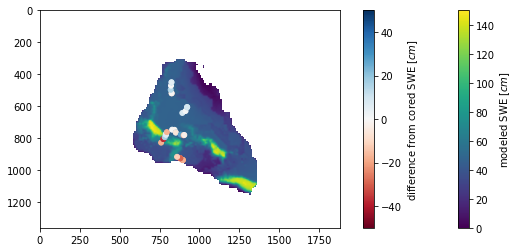

In [51]:
plt.figure(figsize=(10,4))
plt.imshow(data1,vmin=0,vmax=150)
cbar1 = plt.colorbar(); cbar1.set_label('modeled SWE [$cm$]')
plt.scatter(x_idxs, y_idxs, c=diff, cmap='RdBu',marker='o',s=25,vmin=-50, vmax=50)
cbar2 = plt.colorbar(); cbar2.set_label('difference from cored SWE [$cm$]')
# plt.title(fname1+' - '+fname2)
plt.show()

# 5) Compare radar data

In [5]:
all_radar_dfs = pd.read_csv('/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/all_rds_lidar0removed.csv')
all_radar_dfs

,Unnamed: 0,rd_id,UTMx,UTMy,Isurf,Iground,TWT_surf,TWT_ground,rd_xidx,radar_depth_cm
0,0,rd01,519867.619504,4.768088e+06,539.0,1754.0,6.154658e-09,2.002833e-08,52.0,115
1,1,rd01,519867.614812,4.768088e+06,539.0,1756.0,6.154658e-09,2.005117e-08,53.0,115
2,2,rd01,519867.610043,4.768088e+06,539.0,1758.0,6.154658e-09,2.007401e-08,54.0,116
3,3,rd01,519867.605194,4.768088e+06,539.0,1759.0,6.154658e-09,2.008542e-08,55.0,116
4,4,rd01,519867.600276,4.768088e+06,539.0,1761.0,6.154658e-09,2.010826e-08,56.0,116
...,...,...,...,...,...,...,...,...,...,...
115222,115222,rd45,519911.090432,4.768364e+06,485.0,1303.0,5.538050e-09,1.487851e-08,6652.0,64
115223,115223,rd45,519911.104785,4.768364e+06,484.0,1301.0,5.526632e-09,1.485568e-08,6661.0,64
115224,115224,rd45,519911.913311,4.768365e+06,475.0,1272.0,5.423864e-09,1.452454e-08,6981.0,61
115225,115225,rd45,519911.916122,4.768365e+06,473.0,1261.0,5.401026e-09,1.439893e-08,7062.0,60


### calculate densities

In [6]:
# subtract directly from lidar depths
x_idxs = []; y_idxs = []
for i in range(0, len(all_radar_dfs.UTMx)):
    x = all_radar_dfs.UTMx[i]; y = all_radar_dfs.UTMy[i]

    x_idxs.append(np.argmin(np.abs(grid_X-x)))
    y_idxs.append(np.argmin(np.abs(grid_Y-y)))
lidar_depths = lidar_DATA[y_idxs, x_idxs].flatten()

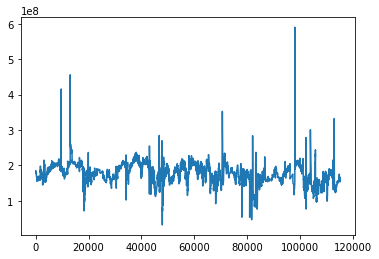

In [52]:
velocities = (lidar_depths/100)/(all_radar_dfs.TWT_ground/2 - all_radar_dfs.TWT_surf/2) # divide TWT by 2
plt.plot(velocities)

2975.0346006870836
-5403.6060292585125


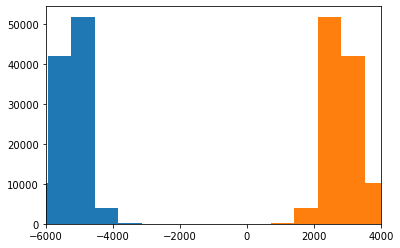

In [51]:
# solve the quadratic equation for rho
a = 0.7
b = 1.7
c = 1-(3e8**2/(velocities**2))
rho1 = (-b + np.sqrt((b**2)-4*a*c))/(2*a)
rho2 = (-b - np.sqrt((b**2)-4*a*c))/(2*a)

print(np.nanmean(rho1*1000)); print(np.nanmean(rho2*1000)) # multiply by 1000 to convert from g/cc to kg/m^3


fig, ax = plt.subplots()
ax.hist(rho2*1000,bins=30)
ax.hist(rho1*1000, bins=30)
plt.xlim(-6000,4000)
plt.show()

### Compare directly with lidar data

In [163]:
# all_radar_dfs= all_radar_dfs[(all_radar_dfs.rd_id == 'rd02') | (all_radar_dfs.rd_id == 'rd03') | (all_radar_dfs.rd_id == 'rd04')]
# all_radar_dfs = all_radar_dfs.reset_index(drop=True)

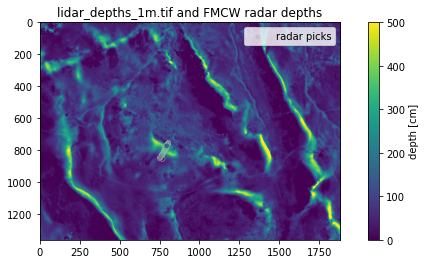

In [117]:
plt.figure(figsize=(10,4))
plt.imshow(data1,vmin=0, vmax=500)
cbar = plt.colorbar(); cbar.set_label('depth [cm]')
plt.scatter(x_idxs, y_idxs, c=all_radar_dfs.radar_depth_cm,marker='o',edgecolor='white',linewidth=0.2,s=25,vmin=0,vmax=500,alpha=0.1)
plt.title(fname1+' and FMCW radar depths')
plt.legend(['radar picks'])
plt.show()

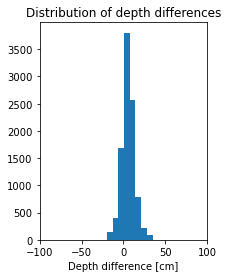

In [119]:
# grab difference in depth at points
gridded_depths_at_points = lidar_DATA[y_idxs, x_idxs].flatten()
diff = gridded_depths_at_points - (all_radar_dfs.radar_depth_cm)

plt.figure(figsize=(3,4))
plt.hist(diff,bins=30)
plt.xlim(-100,100); 
plt.title('Distribution of depth differences'); plt.xlabel('Depth difference [cm]')
plt.show()

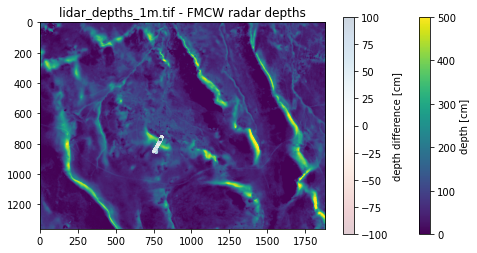

In [123]:
plt.figure(figsize=(8,4))
plt.imshow(data1,vmin=0, vmax=500)
cbar1 = plt.colorbar(); cbar1.set_label('depth [cm]')
plt.scatter(x_idxs, y_idxs, c=diff, cmap='RdBu',marker='o',linewidth=0,s=10,vmin=-100, vmax=100,alpha=0.2)
cbar2 = plt.colorbar(); cbar2.set_label('depth difference [cm]')
plt.title(fname1+' - FMCW radar depths')
plt.show()

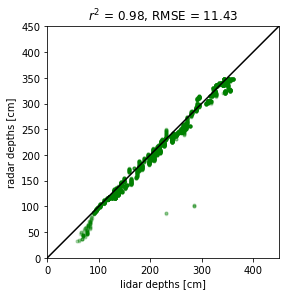

In [128]:
# plot 1 to 1 comparison
from sklearn.metrics import r2_score, mean_squared_error 

plt.scatter(gridded_depths_at_points, all_radar_dfs.radar_depth_cm, marker='.',color='g',alpha=0.1)
plt.plot([0,1000],[0,1000],'k-')
plt.xlim([0,450]); plt.ylim([0,450])
plt.ylabel('radar depths [cm]'); plt.xlabel('lidar depths [cm]')
plt.gca().set_aspect('equal'); plt.tight_layout()

r2 = r2_score(all_radar_dfs.radar_depth_cm,gridded_depths_at_points)
rmse = np.sqrt(mean_squared_error(all_radar_dfs.radar_depth_cm,gridded_depths_at_points))
plt.title('$r^2$ = '+str(round(r2,2))+', RMSE = '+str(round(rmse,2)))
# plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/radar_lidar_1to1_1000scale_100size_1mod.jpg',dpi=200)
plt.show()

### Compare with measured_depths.mat

In [140]:
# grab 3m by 3m lidar grid
new_res = 3
[lidar_DATA, lidar_X, lidar_Y] = read_ground_data_mat(ground_data_folder+'lidar_depths.mat')
lidar_X = lidar_X.flatten(); lidar_Y = lidar_Y.flatten()

# determine where edges lie
edge_X_min = np.min(lidar_X)-0.5; edge_X_max = np.max(lidar_X)+0.5
edge_Y_top = np.max(lidar_Y)+0.5; edge_Y_bottom = np.min(lidar_Y)-0.5

# grab edge coordinates and center coordinates of the grid
edge_X = np.arange(edge_X_min, edge_X_max+1, new_res); edge_Y = np.arange(edge_Y_top, edge_Y_bottom-1, -new_res)
center_X = np.arange(edge_X_min+new_res/2, edge_X_max, new_res); center_Y = np.arange(edge_Y_top, edge_Y_bottom+new_res/2, -new_res)

In [135]:
edge_Y_top

4768996.5

In [141]:
# create an empty grid to hold radar data
radar_grid = np.zeros((len(center_Y), len(center_X)))
measured_depths = DATA_in.flatten()
mean_radar = []; mean_measured = []; xs = []; ys = []

# for each grid cell, grab the edge coordinates
for j in range(0, len(center_X)):
    for i in range(0, len(center_Y)):
        x1 = edge_X[j]; x2 = edge_X[j+1]; y1 = edge_Y[i]; y2 = edge_Y[i+1]

        # grab all radar points within each cell
        radar_within = all_radar_dfs[(all_radar_dfs.UTMx >= x1) & (all_radar_dfs.UTMx <x2) & (all_radar_dfs.UTMy >= y2) & (all_radar_dfs.UTMy < y1)]

        # grab all measured points within each cell
        measured_within = measured_depths[(X_in >= x1) & (X_in < x2) & (Y_in >= y2) & (Y_in < y1)]

        # calculate differences where there is overlap
        if (len(radar_within) > 0) & (len(measured_within > 0)):
            mean_radar.append(np.nanmean(radar_within.radar_depth_cm))
            mean_measured.append(np.nanmean(measured_within))
            xs.append(center_X[j]); ys.append(center_Y[i])
            

        # # fill radar grid
        # if len(radar_within) > 0:
        #     # print(x1, x2, y1, y2)
        #     # print(radar_within.depth)
        #     radar_grid[i,j] = np.nanmean(radar_within.depth) # raw average of the depths
        # else:
        #     radar_grid[i,j] = np.NaN # enter NaN if no radar points found

In [142]:
# create dataframe with 
comparison_df = pd.DataFrame(list(zip(xs, ys, mean_radar, mean_measured)), 
             columns=['utmX','utmY','radar_depth_cm','measured_depth_cm'])
comparison_df

,utmX,utmY,radar_depth_cm,measured_depth_cm
0,519772.0,4768156.5,107.647727,125.000000
1,519775.0,4768162.5,127.884735,145.000000
2,519778.0,4768171.5,204.944444,213.000000
3,519778.0,4768168.5,190.121406,205.333333
4,519781.0,4768174.5,235.331429,247.333333
5,519781.0,4768171.5,220.560127,232.333333
6,519784.0,4768180.5,247.986842,266.666667
7,519784.0,4768177.5,246.725000,261.000000
8,519787.0,4768186.5,298.857143,310.000000
9,519787.0,4768183.5,288.984772,280.000000


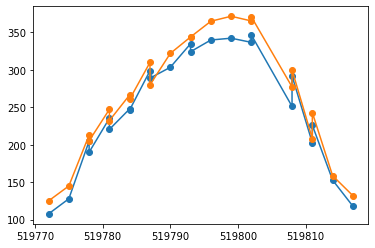

In [161]:
plt.plot(comparison_df.utmX, comparison_df.radar_depth_cm, 'o-')
plt.plot(comparison_df.utmX, comparison_df.measured_depth_cm, 'o-')
plt.show()

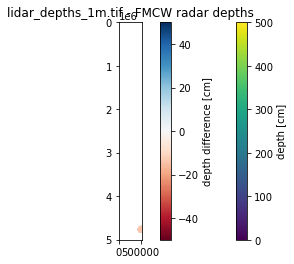

In [152]:
plt.figure(figsize=(8,4))
plt.imshow(data1,vmin=0, vmax=500)
cbar1 = plt.colorbar(); cbar1.set_label('depth [cm]')
plt.scatter(comparison_df.utmX, comparison_df.utmY, cmap='RdBu',c=comparison_df.radar_depth_cm - comparison_df.measured_depth_cm,
           vmin=-50, vmax=50)
cbar2 = plt.colorbar(); cbar2.set_label('depth difference [cm]')
plt.title(fname1+' - FMCW radar depths')
plt.show()

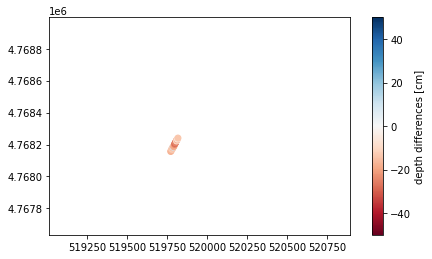

In [150]:
# fig, ax = plt.subplots(figsize=(8,4))
# im = ax.imshow(data1,cmap='Greys_r',vmin=0, vmax=500)
# scax = ax.scatter(comparison_df.utmX, comparison_df.utmY, cmap='RdBu',c=comparison_df.radar_depth_cm - comparison_df.measured_depth_cm,
#            vmin=-50, vmax=50)
# cbar = plt.colorbar(scax)
# cbar.set_label('depth differences [cm]')
# plt.gca().set_aspect('equal')
# plt.xlim(519012,520895); plt.ylim(4767635,4768996)
# plt.show()

In [296]:
# # show the grid - why won't it display?
# fig, ax = plt.subplots()
# plt.imshow(radar_grid,vmin=0, vmax=2); plt.colorbar()
# ax.set_facecolor('black')
# plt.show()

In [ ]:
# IDW for each grid center point (maximum distance?)
def simple_idw(x, y, z, xi, yi, power=2):
    """
    Performs Inverse Distance Weighting (IDW) interpolation.

    Args:
        x (np.ndarray): X-coordinates of known points.
        y (np.ndarray): Y-coordinates of known points.
        z (np.ndarray): Values at known points.
        xi (np.ndarray): X-coordinates of points to interpolate.
        yi (np.ndarray): Y-coordinates of points to interpolate.
        power (int): Power parameter for distance weighting.

    Returns:
        np.ndarray: Interpolated values at (xi, yi).
    """
    # Create a grid of unknown points
    points = np.vstack((x, y)).T
    interp_points = np.vstack((xi, yi)).T

    # Calculate distances between known and unknown points
    # This creates a matrix where rows are unknown points and columns are known points
    dist_matrix = np.sqrt(np.sum((interp_points[:, np.newaxis, :] - points[np.newaxis, :, :])**2, axis=2))

    # Handle cases where distance is zero (unknown point coincides with a known point)
    # Set weight to 1 for the coinciding point and 0 for others
    dist_matrix[dist_matrix == 0] = np.inf # Avoid division by zero, set to infinity
    weights = 1.0 / (dist_matrix ** power)
    
    # Normalize weights so they sum to 1 for each interpolated point
    sum_of_weights = np.sum(weights, axis=1, keepdims=True)
    weights_normalized = weights / sum_of_weights

    # Calculate the weighted average
    zi = np.dot(weights_normalized, z)
    return zi

In [324]:
all_radar_dfs.head()

,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.2,level_0,Unnamed: 0.1.1,index,Unnamed: 0.1.1.1,x,y,depth,Isurf,Iground,x_idx,lidar_depth,rd_id,Unnamed: 0.4,Unnamed: 0.3
0,17,17,2513.0,2513.0,2513,2513.0,2513.0,519812.713912,4.768505e+06,123.532549,533.0,1818.0,2646.0,120.251465,rd29,NaN,NaN
1,18,18,2514.0,2514.0,2514,2514.0,2514.0,519812.707143,4.768505e+06,123.275629,534.0,1817.0,2647.0,120.251465,rd29,NaN,NaN
2,19,19,2515.0,2515.0,2515,2515.0,2515.0,519812.700370,4.768505e+06,123.275629,534.0,1817.0,2648.0,120.251465,rd29,NaN,NaN
3,20,20,2516.0,2516.0,2516,2516.0,2516.0,519812.693603,4.768505e+06,123.147169,534.0,1816.0,2649.0,120.251465,rd29,NaN,NaN
4,21,21,2517.0,2517.0,2517,2517.0,2517.0,519812.686837,4.768505e+06,123.147169,534.0,1816.0,2650.0,120.251465,rd29,NaN,NaN


In [325]:
comparison_df.radar_depth_cm - comparison_df.measured_depth_cm

0     86.650549
1    286.200421
2     86.255863
3     63.250102
dtype: float64